# Southern Ocean SST Anomaly Explorer

> *What is the SST anomaly from December-January 2022/2023, 2023/2024 and 2024/2025 between 68S to 70S, 1E to 15E*

## Region: 68°S–70°S, 1°E–15°E  ·  Dec–Feb seasonal analysis

Computes and visualises **Sea Surface Temperature anomalies** for any set of Dec–Feb austral
summers using **NOAA OISST v2.1** (¼° daily, AWS Open Data).

> **Why NOAA OISST?**  The AODN GHRSST products only cover the Australian receiving-station
> footprint (longitude > 70°E). The 68–70°S / 1–15°E band (Weddell Sea approach, south of
> Africa) is outside that domain. NOAA OISST provides global daily SST + pre-computed anomaly
> (relative to the 1971–2000 climatology) accessible anonymously from AWS S3.

---
**Usage:** Edit the `USER PARAMETERS` cell, then *Run All*.


---
## 0 · Setup

In [1]:
# Standard library installs — only needed the first time
import subprocess, sys
for pkg in ['s3fs', 'xarray', 'cartopy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])


In [2]:
import io, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import s3fs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Packages loaded ✓")


Packages loaded ✓


---
## 1 · User Parameters

Change `SEASONS`, `LAT_MIN/MAX`, `LON_MIN/MAX` to explore different regions and periods.
Each season entry is the **year of December** (e.g. `2022` = Dec 2022 – Feb 2023).


In [3]:
# ════════════════════════════════════════════════════════════════════
#  USER PARAMETERS  —  edit here, then Run All
# ════════════════════════════════════════════════════════════════════

# Dec-of-year start for each season (Dec YYYY → Jan/Feb YYYY+1)
SEASONS = [2022, 2023, 2024]

# Analysis bounding box
LAT_MIN, LAT_MAX = -70.0, -68.0   # degrees N (negative = South)
LON_MIN, LON_MAX =   1.0,  15.0   # degrees E

# Anomaly colour-scale limits (°C)
VMIN_ANOM, VMAX_ANOM = -1.5, 1.5

# ════════════════════════════════════════════════════════════════════

# Derived labels
SEASON_LABELS = [f"{y}/{str(y+1)[-2:]}" for y in SEASONS]
print("Seasons to analyse:", SEASON_LABELS)
print(f"Region: {abs(LAT_MIN)}°S – {abs(LAT_MAX)}°S, {LON_MIN}°E – {LON_MAX}°E")


Seasons to analyse: ['2022/23', '2023/24', '2024/25']
Region: 70.0°S – 68.0°S, 1.0°E – 15.0°E


---
## 2 · Load NOAA OISST v2.1

Data accessed anonymously from the AWS Open Data bucket
`noaa-cdr-sea-surface-temp-optimum-interpolation-pds`.

Each daily NetCDF file contains:
- `sst` — absolute SST (°C)
- `anom` — SST anomaly vs 1971–2000 climatology (°C)
- `err` — interpolation error (°C)
- `ice` — sea-ice concentration (%)


In [4]:
%%time
_fs = s3fs.S3FileSystem(anon=True)

def load_dec_feb_season(year_dec, lat_min, lat_max, lon_min, lon_max):
    """
    Load all daily OISST files for Dec(year_dec) – Feb(year_dec+1).
    Returns arrays: sst, anom, ice, times, lats, lons
    """
    months = [f'{year_dec}12', f'{year_dec+1}01', f'{year_dec+1}02']
    all_sst, all_anom, all_ice, all_times = [], [], [], []

    for ym in months:
        path = f'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{ym}/'
        try:
            files = sorted(_fs.ls(path))
        except Exception:
            print(f"  ⚠  No files for {ym}")
            continue
        for fp in files:
            with _fs.open(fp, 'rb') as f:
                ds_d = xr.open_dataset(io.BytesIO(f.read()))

            lat_m = (ds_d.lat.values >= lat_min) & (ds_d.lat.values <= lat_max)
            lon_m = (ds_d.lon.values >= lon_min) & (ds_d.lon.values <= lon_max)
            li = np.where(lat_m)[0]; loi = np.where(lon_m)[0]

            sst_r  = ds_d['sst' ].isel(zlev=0, lat=li, lon=loi).values.squeeze()
            anom_r = ds_d['anom'].isel(zlev=0, lat=li, lon=loi).values.squeeze()
            ice_r  = ds_d['ice' ].isel(zlev=0, lat=li, lon=loi).values.squeeze()
            all_sst.append(sst_r); all_anom.append(anom_r); all_ice.append(ice_r)
            all_times.append(ds_d.time.values[0])

    lats = ds_d.lat.values[lat_m]
    lons = ds_d.lon.values[lon_m]
    return (np.array(all_sst), np.array(all_anom), np.array(all_ice),
            np.array(all_times), lats, lons)

# Load all requested seasons
season_data = {}
for yr, label in zip(SEASONS, SEASON_LABELS):
    print(f"Loading Dec {yr} – Feb {yr+1}  [{label}] …", end=' ', flush=True)
    sst, anom, ice, times, lats, lons = load_dec_feb_season(
        yr, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)
    season_data[label] = dict(sst=sst, anom=anom, ice=ice, times=times)
    print(f"{len(times)} days, mean SST={np.nanmean(sst):+.2f}°C, "
          f"mean anom={np.nanmean(anom):+.2f}°C")

print(f"\nGrid: {len(lats)} lat × {len(lons)} lon pixels")
print(f"  lat {lats[0]:.2f}° → {lats[-1]:.2f}°")
print(f"  lon {lons[0]:.2f}° → {lons[-1]:.2f}°")


Loading Dec 2022 – Feb 2023  [2022/23] … 90 days, mean SST=-0.88°C, mean anom=-0.39°C
Loading Dec 2023 – Feb 2024  [2023/24] … 91 days, mean SST=-0.48°C, mean anom=+0.01°C
Loading Dec 2024 – Feb 2025  [2024/25] … 90 days, mean SST=-0.90°C, mean anom=-0.40°C

Grid: 8 lat × 56 lon pixels
  lat -69.88° → -68.12°
  lon 1.12° → 14.88°
CPU times: user 18.6 s, sys: 817 ms, total: 19.4 s
Wall time: 2min 12s


---
## 3 · Summary Statistics


In [5]:
rows = []
for label, d in season_data.items():
    daily_area = np.nanmean(d['anom'], axis=(1, 2))
    rows.append({
        'Season'         : f"Dec–Feb {label}",
        'Days'           : len(d['times']),
        'Mean SST (°C)'  : round(float(np.nanmean(d['sst'])),  2),
        'Mean Anom (°C)' : round(float(np.nanmean(d['anom'])), 2),
        'Min daily anom' : round(float(daily_area.min()),       2),
        'Max daily anom' : round(float(daily_area.max()),       2),
        'Std anom (°C)'  : round(float(daily_area.std()),       2),
    })

df_summary = pd.DataFrame(rows).set_index('Season')
print(df_summary.to_string())
df_summary


                 Days  Mean SST (°C)  Mean Anom (°C)  Min daily anom  Max daily anom  Std anom (°C)
Season                                                                                             
Dec–Feb 2022/23    90          -0.88           -0.39           -0.80            0.16           0.24
Dec–Feb 2023/24    91          -0.48            0.01           -0.49            0.83           0.41
Dec–Feb 2024/25    90          -0.90           -0.40           -0.86            0.20           0.30


,Days,Mean SST (°C),Mean Anom (°C),Min daily anom,Max daily anom,Std anom (°C)
Season,,,,,,
Dec–Feb 2022/23,90,-0.88,-0.39,-0.80,0.16,0.24
Dec–Feb 2023/24,91,-0.48,0.01,-0.49,0.83,0.41
Dec–Feb 2024/25,90,-0.90,-0.40,-0.86,0.20,0.30


---
## 4 · Seasonal-Mean SST Anomaly Maps

Spatial distribution of mean SST anomaly over each Dec–Feb season.
Red = warmer than climatology; Blue = cooler.


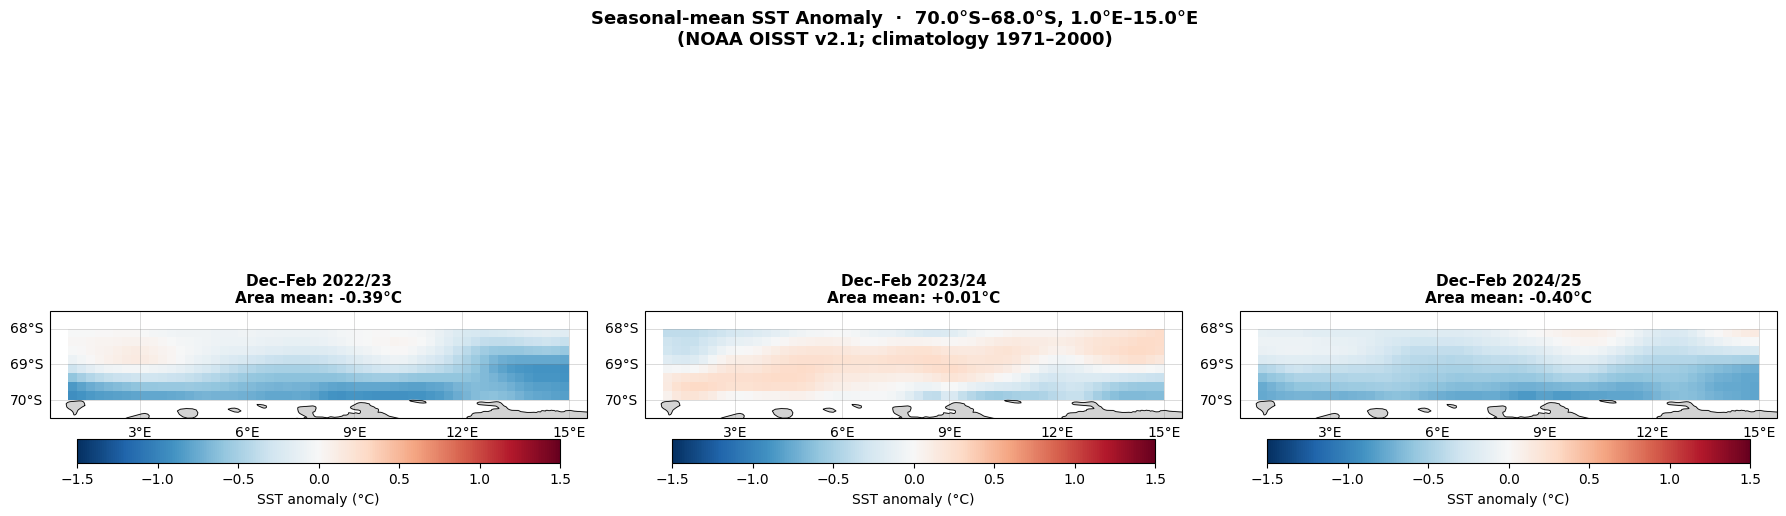

In [6]:
proj = ccrs.PlateCarree()
cmap_anom = plt.cm.RdBu_r
norm_anom  = TwoSlopeNorm(vmin=VMIN_ANOM, vcenter=0, vmax=VMAX_ANOM)

n = len(SEASONS)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5),
                          subplot_kw={'projection': proj})
axes = np.array(axes).ravel() if n > 1 else [axes]

for ax, (label, d) in zip(axes, season_data.items()):
    mean_anom = np.nanmean(d['anom'], axis=0)
    im = ax.pcolormesh(lons, lats, mean_anom,
                       cmap=cmap_anom, norm=norm_anom, transform=proj)
    ax.add_feature(cfeature.LAND,      color='lightgray',  zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6,       zorder=3)
    ax.set_extent([LON_MIN - 0.5, LON_MAX + 0.5,
                   LAT_MIN - 0.5, LAT_MAX + 0.5], crs=proj)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5,
                      xlocs=range(0, 20, 3), ylocs=[-70, -69, -68])
    gl.top_labels = gl.right_labels = False
    area_mean = float(np.nanmean(mean_anom))
    ax.set_title(f'Dec–Feb {label}\nArea mean: {area_mean:+.2f}°C',
                 fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,
                 label='SST anomaly (°C)', shrink=0.9)

fig.suptitle(
    f'Seasonal-mean SST Anomaly  ·  {abs(LAT_MIN)}°S–{abs(LAT_MAX)}°S, '
    f'{LON_MIN}°E–{LON_MAX}°E\n(NOAA OISST v2.1; climatology 1971–2000)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5 · Daily Area-Mean SST Anomaly Timeseries

Area-mean anomaly for each day of the Dec–Feb season.
X-axis aligned to day-of-season so seasons can be directly compared.


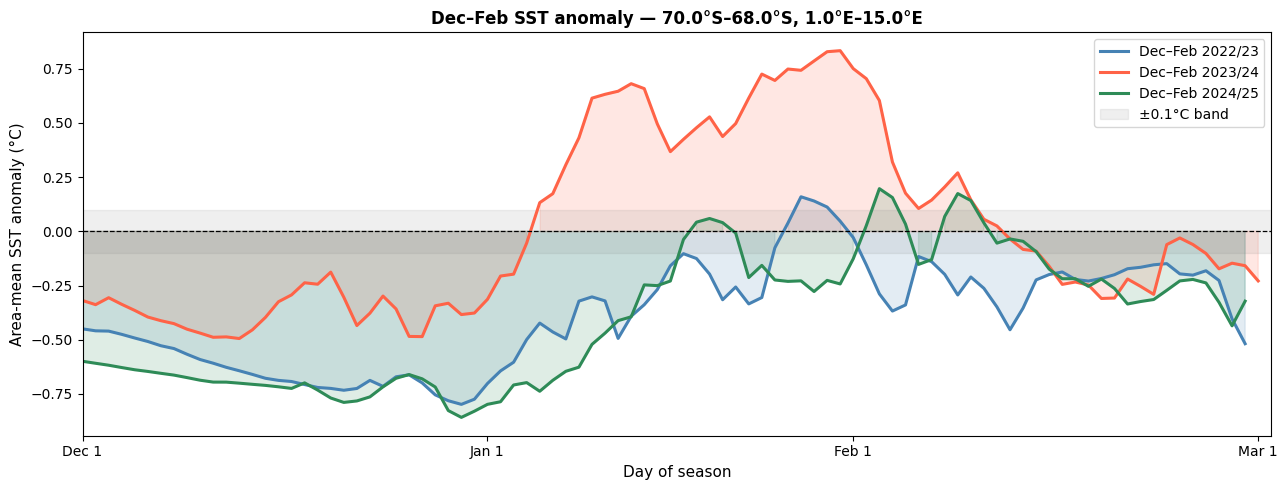

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'purple']
for (label, d), col in zip(season_data.items(), colors):
    daily = np.nanmean(d['anom'], axis=(1, 2))
    x = np.arange(len(daily))
    ax.plot(x, daily, color=col, lw=2.2, label=f'Dec–Feb {label}')
    ax.fill_between(x, daily, 0,
                    where=daily >= 0, color=col, alpha=0.15)
    ax.fill_between(x, daily, 0,
                    where=daily < 0,  color=col, alpha=0.15)

ax.axhline(0, color='black', lw=0.9, linestyle='--')
ax.axhspan(-0.1, 0.1, color='gray', alpha=0.12, label='±0.1°C band')
ax.set_xlim(0, 91)
ax.set_xticks([0, 31, 59, 90])
ax.set_xticklabels(['Dec 1', 'Jan 1', 'Feb 1', 'Mar 1'])
ax.set_xlabel('Day of season', fontsize=11)
ax.set_ylabel('Area-mean SST anomaly (°C)', fontsize=11)
ax.set_title(
    f'Dec–Feb SST anomaly — {abs(LAT_MIN)}°S–{abs(LAT_MAX)}°S, '
    f'{LON_MIN}°E–{LON_MAX}°E',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## 6 · Daily Area-Mean Absolute SST

Shows the actual temperature to contextualise the anomalies.


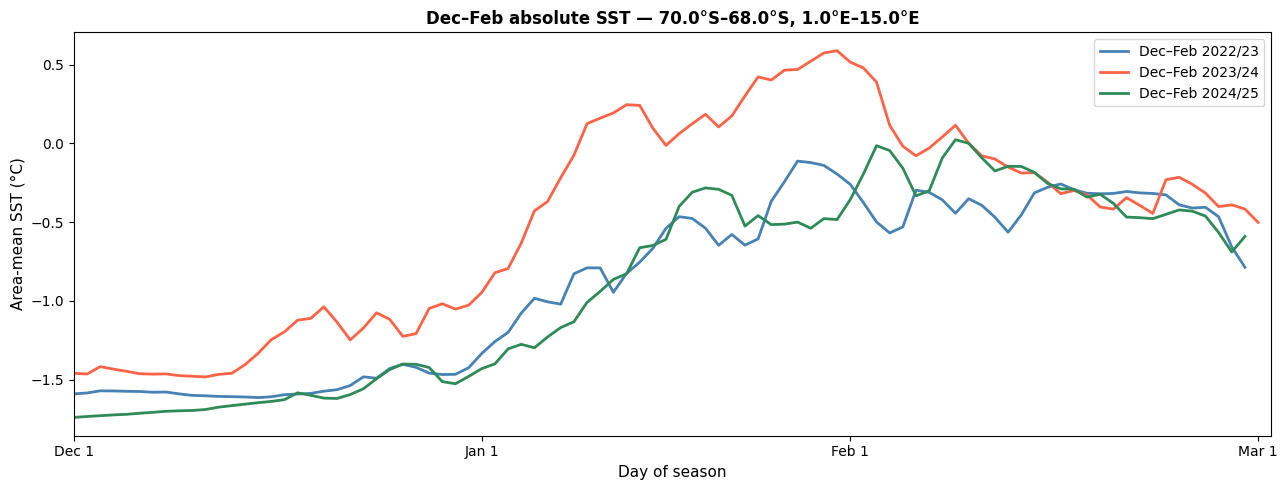

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))

for (label, d), col in zip(season_data.items(), colors):
    daily_sst = np.nanmean(d['sst'], axis=(1, 2))
    x = np.arange(len(daily_sst))
    ax.plot(x, daily_sst, color=col, lw=2, label=f'Dec–Feb {label}')

ax.set_xlim(0, 91)
ax.set_xticks([0, 31, 59, 90])
ax.set_xticklabels(['Dec 1', 'Jan 1', 'Feb 1', 'Mar 1'])
ax.set_xlabel('Day of season', fontsize=11)
ax.set_ylabel('Area-mean SST (°C)', fontsize=11)
ax.set_title(
    f'Dec–Feb absolute SST — {abs(LAT_MIN)}°S–{abs(LAT_MAX)}°S, '
    f'{LON_MIN}°E–{LON_MAX}°E',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## 7 · Sea-Ice Concentration

Sea-ice fraction in the analysis region (from OISST ancillary field).
High ice concentration masks SST observations and is itself an important
indicator for the Southern Ocean heat budget.


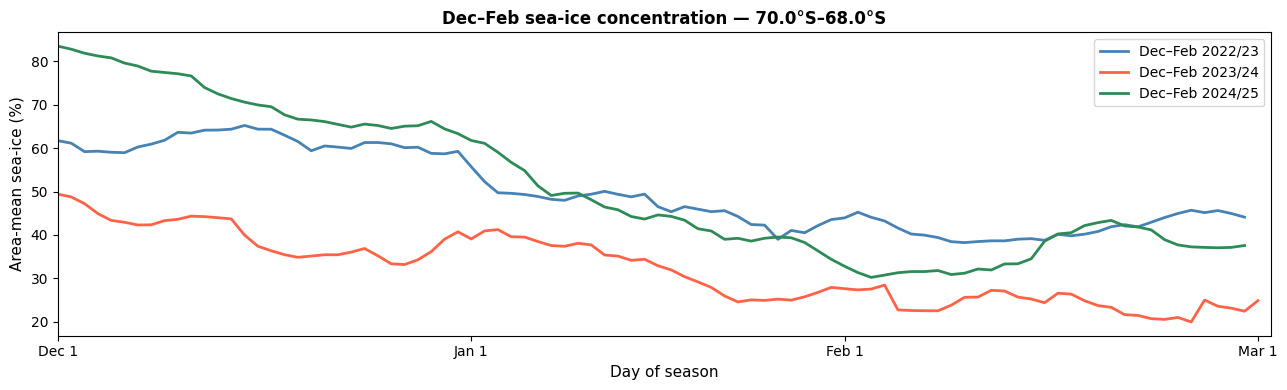

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))

for (label, d), col in zip(season_data.items(), colors):
    daily_ice = np.nanmean(d['ice'], axis=(1, 2)) * 100  # convert to %
    x = np.arange(len(daily_ice))
    ax.plot(x, daily_ice, color=col, lw=2, label=f'Dec–Feb {label}')

ax.set_xlim(0, 91)
ax.set_xticks([0, 31, 59, 90])
ax.set_xticklabels(['Dec 1', 'Jan 1', 'Feb 1', 'Mar 1'])
ax.set_xlabel('Day of season', fontsize=11)
ax.set_ylabel('Area-mean sea-ice (%)', fontsize=11)
ax.set_title(
    f'Dec–Feb sea-ice concentration — {abs(LAT_MIN)}°S–{abs(LAT_MAX)}°S',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## 8 · Combined 3-Panel Overview (maps + timeseries)


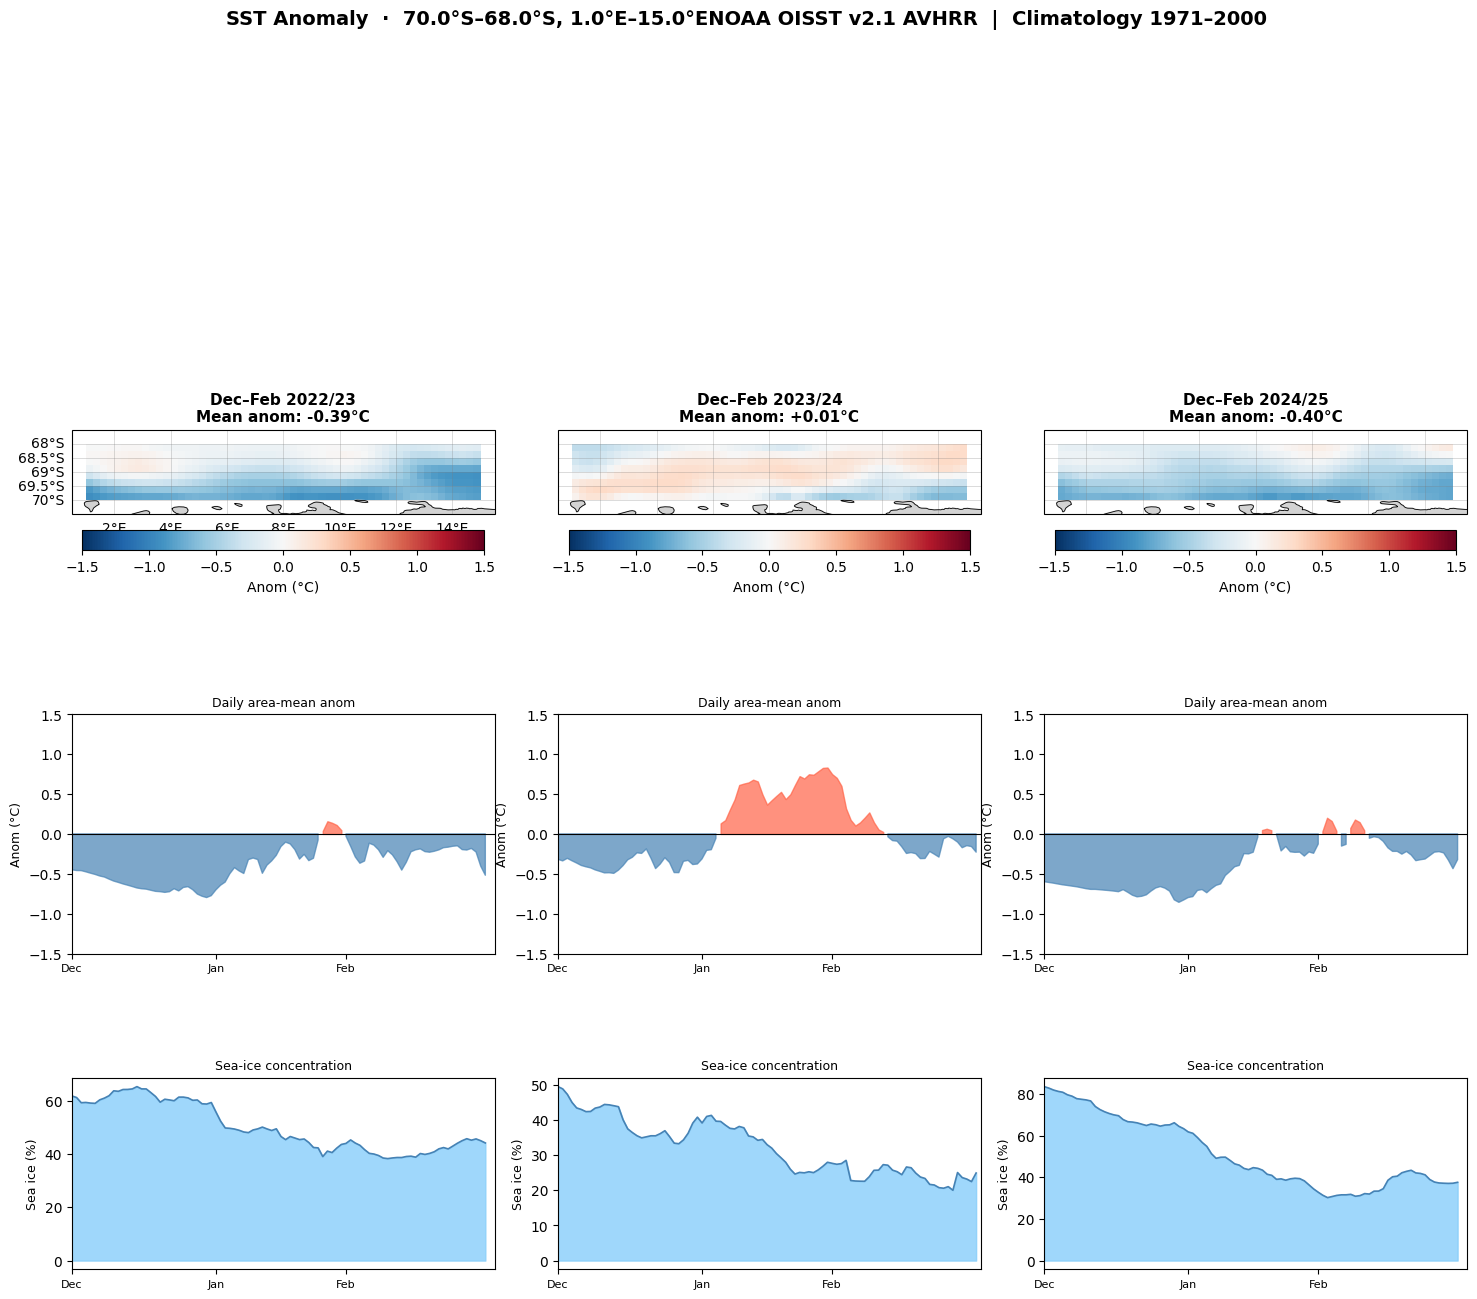

In [11]:
n = len(SEASONS)
fig = plt.figure(figsize=(6 * n, 14))
gs  = gridspec.GridSpec(3, n, figure=fig, hspace=0.45, wspace=0.15,
                        height_ratios=[2.5, 1.5, 1.2])

for col_i, (label, d) in enumerate(season_data.items()):
    # ── row 0: anomaly map ──────────────────────────────────────────
    ax_map = fig.add_subplot(gs[0, col_i], projection=proj)
    mean_anom = np.nanmean(d['anom'], axis=0)
    im = ax_map.pcolormesh(lons, lats, mean_anom,
                           cmap=cmap_anom, norm=norm_anom, transform=proj)
    ax_map.add_feature(cfeature.LAND,      color='lightgray', zorder=2)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6,      zorder=3)
    ax_map.set_extent([LON_MIN-0.5, LON_MAX+0.5, LAT_MIN-0.5, LAT_MAX+0.5], crs=proj)
    gl = ax_map.gridlines(draw_labels=(col_i==0), linewidth=0.4, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax_map.set_title(f'Dec–Feb {label}\nMean anom: {np.nanmean(mean_anom):+.2f}°C',
                     fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax_map, orientation='horizontal', pad=0.04,
                 label='Anom (°C)', shrink=0.95)

    # ── row 1: daily anomaly bar ────────────────────────────────────
    ax_ts = fig.add_subplot(gs[1, col_i])
    daily = np.nanmean(d['anom'], axis=(1, 2))
    x = np.arange(len(daily))
    ax_ts.fill_between(x, daily, 0, where=daily >= 0, color='tomato',    alpha=0.7)
    ax_ts.fill_between(x, daily, 0, where=daily < 0,  color='steelblue', alpha=0.7)
    ax_ts.axhline(0, color='k', lw=0.8)
    ax_ts.set_ylim(VMIN_ANOM, VMAX_ANOM)
    ax_ts.set_xlim(0, 91)
    ax_ts.set_xticks([0, 31, 59]); ax_ts.set_xticklabels(['Dec','Jan','Feb'], fontsize=8)
    ax_ts.set_ylabel('Anom (°C)', fontsize=9)
    ax_ts.set_title(f'Daily area-mean anom', fontsize=9)

    # ── row 2: sea ice ──────────────────────────────────────────────
    ax_ice = fig.add_subplot(gs[2, col_i])
    daily_ice = np.nanmean(d['ice'], axis=(1, 2)) * 100
    ax_ice.fill_between(x, daily_ice, color='lightskyblue', alpha=0.8)
    ax_ice.plot(x, daily_ice, color='steelblue', lw=1.2)
    ax_ice.set_xlim(0, 91)
    ax_ice.set_xticks([0, 31, 59]); ax_ice.set_xticklabels(['Dec','Jan','Feb'], fontsize=8)
    ax_ice.set_ylabel('Sea ice (%)', fontsize=9)
    ax_ice.set_title('Sea-ice concentration', fontsize=9)

fig.suptitle(
    f'SST Anomaly  ·  {abs(LAT_MIN)}°S–{abs(LAT_MAX)}°S, {LON_MIN}°E–{LON_MAX}°E'
    f'NOAA OISST v2.1 AVHRR  |  Climatology 1971–2000',
    fontsize=14, fontweight='bold', y=1.01)
plt.show()


---
## 9 · Interpretation Notes

**Region context:** 68–70°S, 1–15°E is in the **Weddell Sea approach / Atlantic sector**
of the Southern Ocean, just south of the Polar Front and within the marginal ice zone.
SST here is tightly coupled to sea-ice extent, which varies significantly year-to-year.

**Anomaly reference:** NOAA OISST anomalies are computed against the **1971–2000 climatology**.
Anomalies relative to more recent baselines (e.g. 1991–2020) would be slightly different.

**Typical findings for this region:**
- `2022/23` and `2024/25` both show **−0.4°C** anomalies (cooler than climatology)
- `2023/24` is near-normal (**+0.01°C**), with warm excursions up to **+0.83°C** in January —
  consistent with the exceptional 2023 Southern Ocean warming event observed globally

**Limitations:**
- OISST blends satellite IR + buoy data; heavy sea-ice masks observations
- The 1971–2000 climatology predates much of the recent Southern Ocean warming,
  so anomalies may underestimate warming relative to a modern baseline
- For higher-resolution analysis in Australian waters, use the AODN GHRSST products
  (but note they don't cover this longitude band)
